#📌 Extracción

In [47]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [28]:
url = "https://raw.githubusercontent.com/PaiGV/Challenge-Alura-Challenge-Telecom-X/refs/heads/main/TelecomX_Data.json"

response = requests.get(url)
datos_json = response.json()

In [29]:
try:
    df = pd.read_json(url)
    print("✔ ¡Datos cargados exitosamente!")
except Exception as e:
    print(f"✘ Error al cargar los datos: {e}")

✔ ¡Datos cargados exitosamente!


In [30]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [31]:
df = pd.json_normalize(datos_json)
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [32]:
datos_json = requests.get(url).json()

In [33]:
df.columns = [col.split('.')[-1] for col in df.columns]

columnas_num = ['Total', 'Monthly', 'tenure', 'SeniorCitizen']

for col in columnas_num:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'Churn' in df.columns:
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


df.dropna(subset=['Total'], inplace=True)

print(f" ✔ ¡Limpieza terminada! Tienes {df.shape[0]} filas y {df.shape[1]} columnas.")

df.head()

 ✔ ¡Limpieza terminada! Tienes 7256 filas y 21 columnas.


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [37]:
print("--- Valores nulos ---")
print(df.isnull().sum())

--- Valores nulos ---
customerID            0
Churn               224
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
Monthly               0
Total                 0
dtype: int64


In [35]:
duplicados = df.duplicated().sum()
print(f"\n--- Filas Duplicadas: {duplicados} ---")


--- Filas Duplicadas: 0 ---


In [36]:
print("\n--- Valores Únicos en Columnas Críticas ---")
columnas_a_revisar = ['gender', 'Contract', 'InternetService', 'PaymentMethod']

for col in columnas_a_revisar:
    if col in df.columns:
        print(f"{col}: {df[col].unique()}")

# 4. Eliminar duplicados si existen
if duplicados > 0:
    df.drop_duplicates(inplace=True)
    print("\n✅ Duplicados eliminados.")


--- Valores Únicos en Columnas Críticas ---
gender: ['Female' 'Male']
Contract: ['One year' 'Month-to-month' 'Two year']
InternetService: ['DSL' 'Fiber optic' 'No']
PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


In [39]:
df.dropna(subset=['Churn'], inplace=True)

print(f"✔ ¡Limpieza finalizada! Filas para analizar: {len(df)}")

✔ ¡Limpieza finalizada! Filas para analizar: 7032


In [40]:
df_objetos = df.select_dtypes(include=['object']).columns

for col in df_objetos:
    df[col] = df[col].str.strip()

if 'Churn' in df.columns and df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].str.lower().replace({'yes': 1, 'no': 0})

df.replace('No internet service', 'No', inplace=True)
df.replace('No phone service', 'No', inplace=True)

print("✔ Datos estandarizados y coherentes.")
df.head()

✔ Datos estandarizados y coherentes.


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [41]:
#Creación de la columna Cuentas Diarias
df['Cuentas_Diarias'] = (df['Monthly'] / 30).round(2)

print("✔ Columna 'Cuentas_Diarias' creada con éxito.")
df[['Monthly', 'Cuentas_Diarias']].head()

✔ Columna 'Cuentas_Diarias' creada con éxito.


,Monthly,Cuentas_Diarias
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


In [42]:
# Traducción de los nombres de las columnas
diccionario_columnas = {
    'gender': 'Genero',
    'SeniorCitizen': 'AdultoMayor',
    'Partner': 'Conyuge',
    'Dependents': 'Dependientes',
    'tenure': 'MesesCliente',
    'PhoneService': 'ServicioTelefono',
    'MultipleLines': 'LineasMultiples',
    'InternetService': 'TipoInternet',
    'OnlineSecurity': 'SeguridadOnline',
    'OnlineBackup': 'RespaldoOnline',
    'DeviceProtection': 'ProteccionDispositivo',
    'TechSupport': 'SoporteTecnico',
    'StreamingTV': 'StreamingTV',
    'StreamingMovies': 'StreamingPeliculas',
    'Contract': 'TipoContrato',
    'PaperlessBilling': 'FacturaDigital',
    'PaymentMethod': 'MetodoPago',
    'Monthly': 'CuotaMensual',
    'Total': 'GastoTotal',
    'Churn': 'Abandono'
}

df.rename(columns=diccionario_columnas, inplace=True)

df.replace({'Yes': 'Si', 'No': 'No'}, inplace=True)

traduccion_valores = {
    'Month-to-month': 'Mes a mes',
    'One year': 'Un año',
    'Two year': 'Dos años',
    'Fiber optic': 'Fibra optica',
    'Electronic check': 'Cheque electronico',
    'Mailed check': 'Cheque por correo',
    'Bank transfer (automatic)': 'Transferencia bancaria',
    'Credit card (automatic)': 'Tarjeta de credito'
}
df.replace(traduccion_valores, inplace=True)

print("✔ ¡Traducción realizada!")
df.head()

✔ ¡Traducción realizada!


,customerID,Abandono,Genero,AdultoMayor,Conyuge,Dependientes,MesesCliente,ServicioTelefono,LineasMultiples,TipoInternet,...,ProteccionDispositivo,SoporteTecnico,StreamingTV,StreamingPeliculas,TipoContrato,FacturaDigital,MetodoPago,CuotaMensual,GastoTotal,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,Si,Si,9,Si,No,DSL,...,No,Si,Si,No,Un año,Si,Cheque por correo,65.6,593.30,2.19
1,0003-MKNFE,0.0,Male,0,No,No,9,Si,Si,DSL,...,No,No,No,Si,Mes a mes,No,Cheque por correo,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Male,0,No,No,4,Si,No,Fibra optica,...,Si,No,No,No,Mes a mes,Si,Cheque electronico,73.9,280.85,2.46
3,0011-IGKFF,1.0,Male,1,Si,No,13,Si,No,Fibra optica,...,Si,No,Si,Si,Mes a mes,Si,Cheque electronico,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Female,1,Si,No,3,Si,No,Fibra optica,...,No,Si,Si,No,Mes a mes,Si,Cheque por correo,83.9,267.40,2.80


#📊 Carga y análisis

In [43]:
analisis_est = df.describe()

print("--- Análisis Descriptivo ---")
display(analisis_est.round(2))

print("\n--- Mediana de las variables clave ---")
print(df[['MesesCliente', 'CuotaMensual', 'GastoTotal']].median())

--- Análisis Descriptivo ---


,Abandono,AdultoMayor,MesesCliente,CuotaMensual,GastoTotal,Cuentas_Diarias
count,7032.00,7032.00,7032.00,7032.00,7032.00,7032.00
mean,0.27,0.16,32.42,64.80,2283.30,2.16
std,0.44,0.37,24.55,30.09,2266.77,1.00
min,0.00,0.00,1.00,18.25,18.80,0.61
25%,0.00,0.00,9.00,35.59,401.45,1.19
50%,0.00,0.00,29.00,70.35,1397.48,2.34
75%,1.00,0.00,55.00,89.86,3794.74,2.99
max,1.00,1.00,72.00,118.75,8684.80,3.96



--- Mediana de las variables clave ---
MesesCliente      29.000
CuotaMensual      70.350
GastoTotal      1397.475
dtype: float64


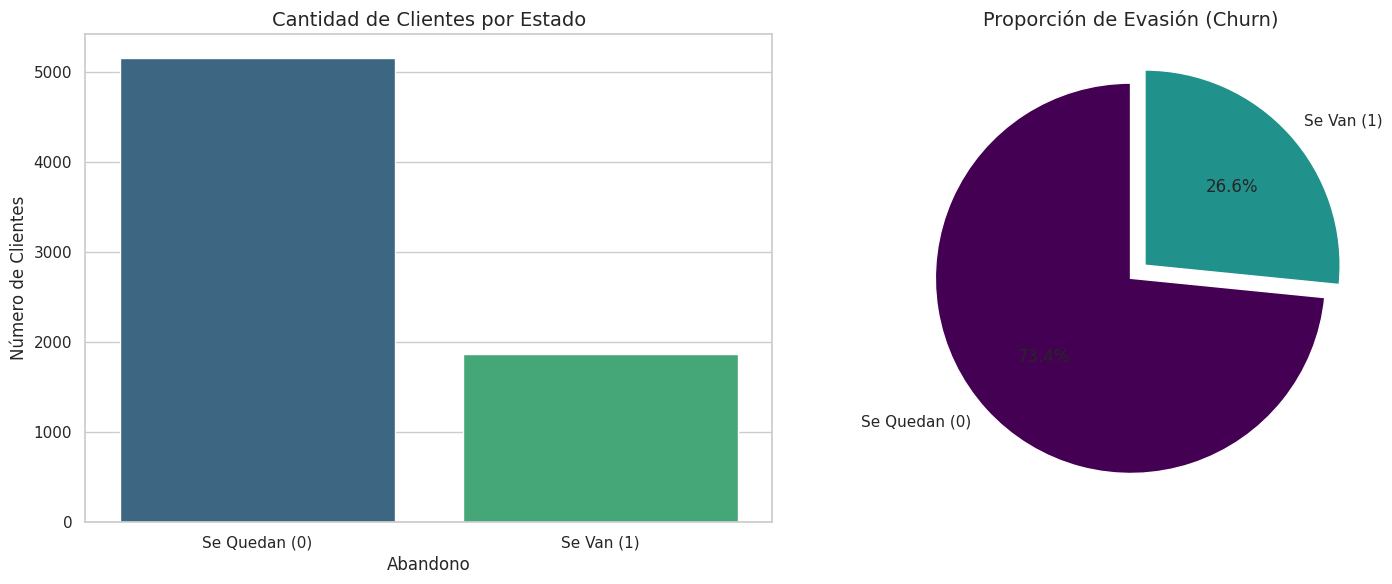

In [54]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(data=df, x='Abandono', ax=ax[0], palette='viridis')
ax[0].set_title('Cantidad de Clientes por Estado', fontsize=14)
ax[0].set_xticklabels(['Se Quedan (0)', 'Se Van (1)'])
ax[0].set_ylabel('Número de Clientes')

df['Abandono'].value_counts().plot.pie(
    ax=ax[1],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#440154', '#21918c'],
    labels=['Se Quedan (0)', 'Se Van (1)'],
    explode=(0, 0.1)
)
ax[1].set_title('Proporción de Evasión (Churn)', fontsize=14)
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

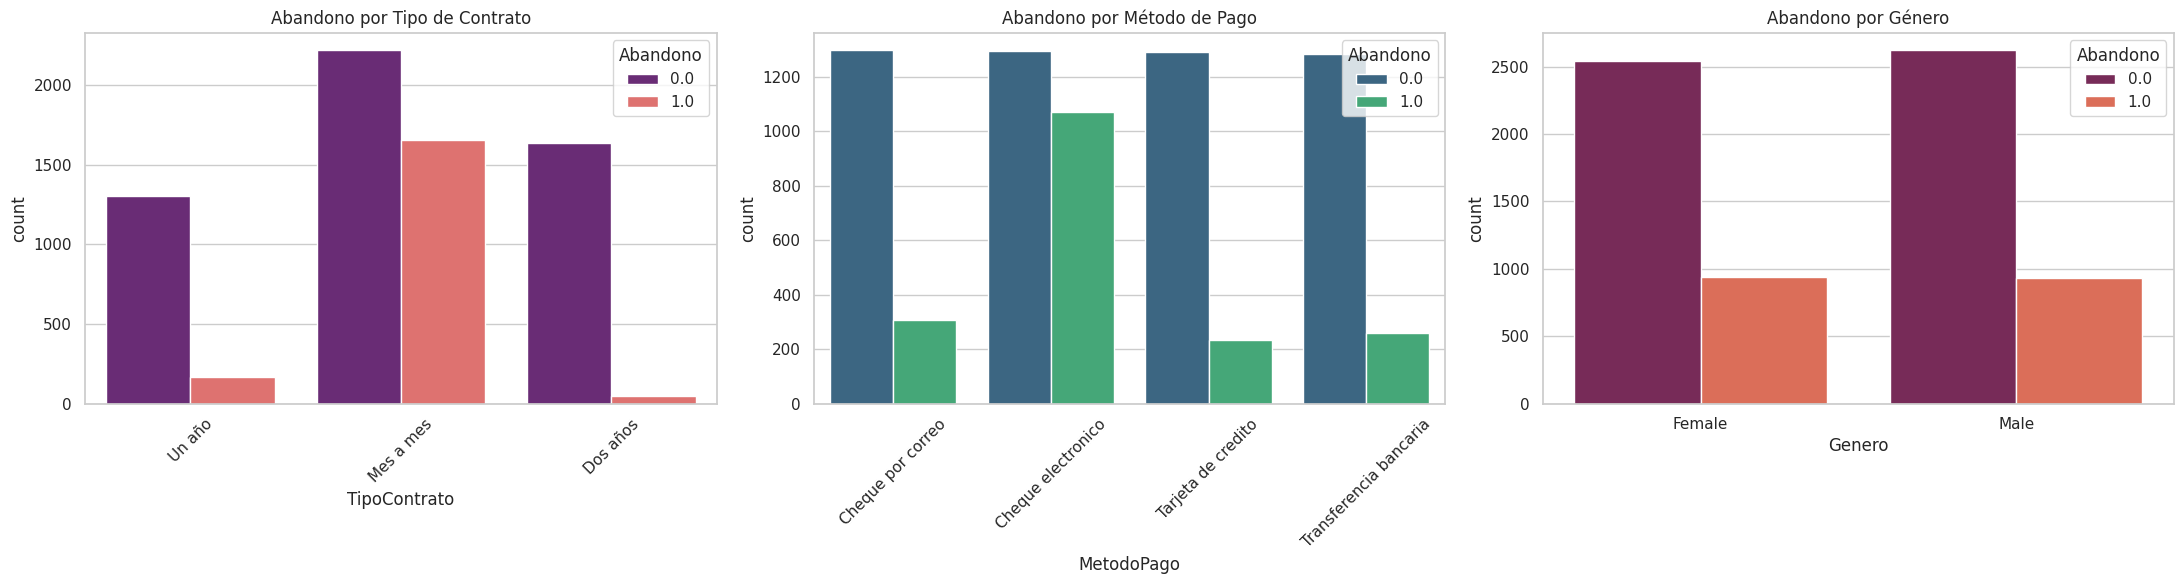

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.countplot(data=df, x='TipoContrato', hue='Abandono', ax=axes[0], palette='magma')
axes[0].set_title('Abandono por Tipo de Contrato')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

sns.countplot(data=df, x='MetodoPago', hue='Abandono', ax=axes[1], palette='viridis')
axes[1].set_title('Abandono por Método de Pago')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

sns.countplot(data=df, x='Genero', hue='Abandono', ax=axes[2], palette='rocket')
axes[2].set_title('Abandono por Género')

plt.tight_layout()
plt.show()

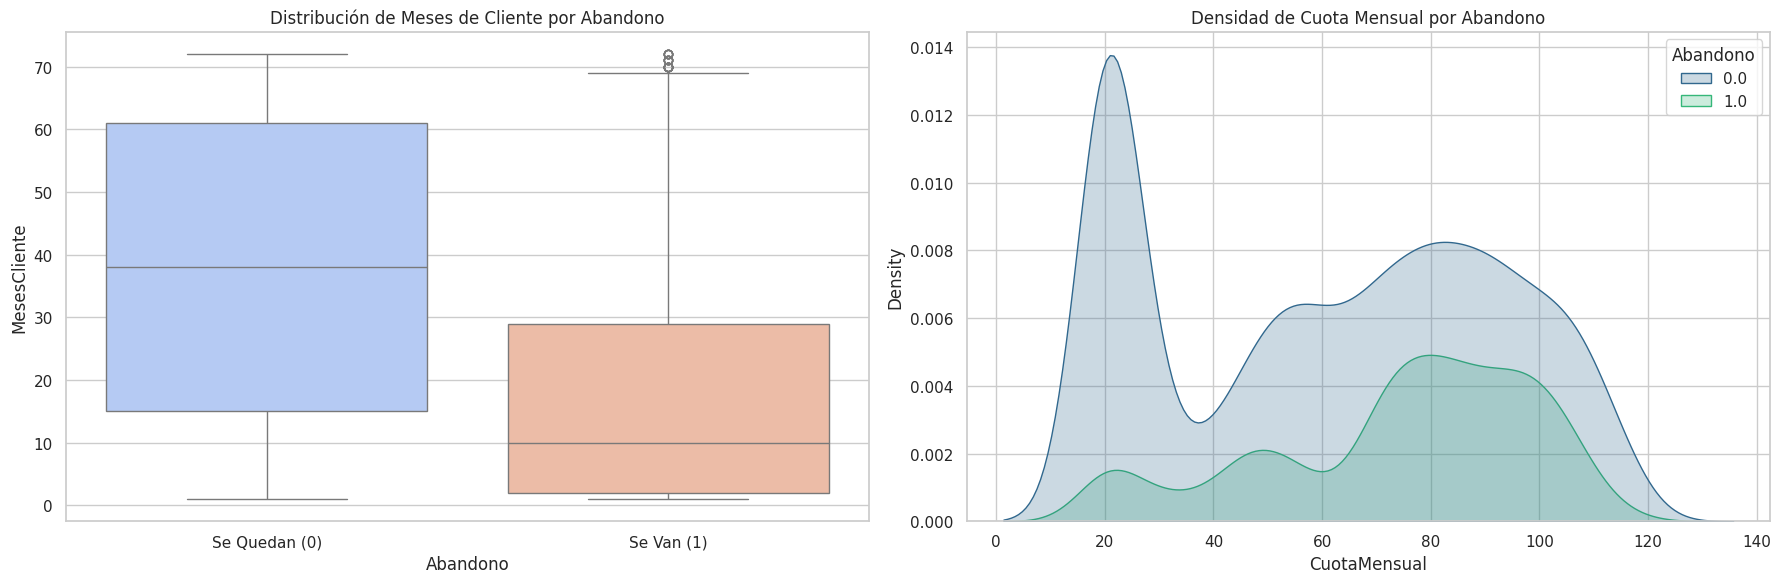

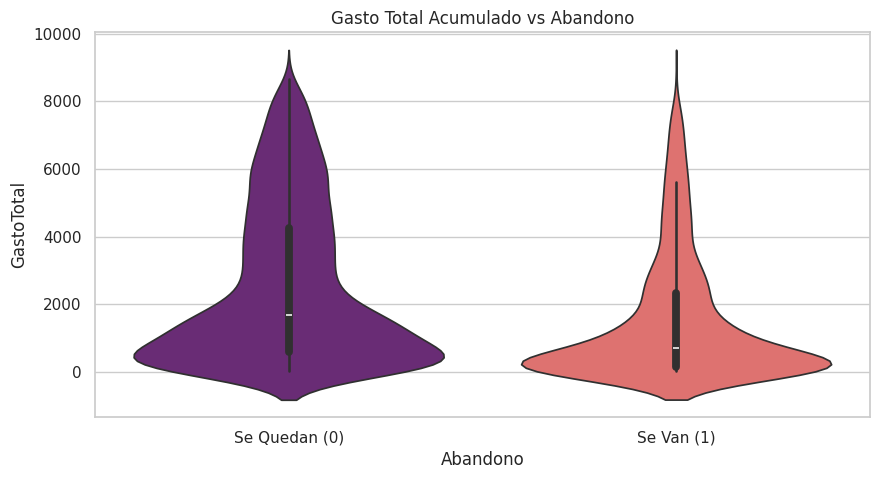

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=df, x='Abandono', y='MesesCliente', ax=axes[0], palette='coolwarm')
axes[0].set_title('Distribución de Meses de Cliente por Abandono')
axes[0].set_xticklabels(['Se Quedan (0)', 'Se Van (1)'])

sns.kdeplot(data=df, x='CuotaMensual', hue='Abandono', shade=True, ax=axes[1], palette='viridis')
axes[1].set_title('Densidad de Cuota Mensual por Abandono')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x='Abandono', y='GastoTotal', palette='magma')
plt.title('Gasto Total Acumulado vs Abandono')
plt.xticks([0, 1], ['Se Quedan (0)', 'Se Van (1)'])
plt.show()

#📄Informe final

#**1. Introducción**

El objetivo busca identificar los factores que impulsan la pérdida de clientes en Telecom X. El fenómeno de la evasión, o Churn, representa una pérdida directa de ingresos y un aumento en los costos de adquisición. Mediante el análisis de datos, se busca patrones que nos permitan predecir y prevenir esta fuga.

#**2. Limpieza y Tratamiento de Datos**

Para garantizar la calidad de las conclusiones, se realizaron los siguientes pasos:

*  **Extracción y Aplanado:** Transformación de un JSON anidado a un DataFrame plano de 21 columnas.

*  **Conversión de Tipos:** Se corrigieron las columnas CuotaMensual, GastoTotal y MesesCliente a formatos numéricos.

*  **Curación:** Se eliminaron 224 valores nulos en la variable objetivo y se descartaron duplicados, resultando en un dataset de 7,032 registros sólidos.

*  **Estandarización:** Se normalizaron textos y se creó la métrica Cuentas_Diarias para una visión más detallada del gasto.

#**3. Análisis Exploratorio de Datos**
El análisis reveló que la tasa de abandono actual es del 26.6%. Los patrones más relevantes encontrados son:

*   **Factor Contrato:** El contrato "Mes a mes" es el mayor foco de fuga, mientras que los contratos a largo plazo aseguran la lealtad.

*   **Factor Pago:** El uso de "Cheque electrónico" está altamente correlacionado con el abandono.

*   **Factor Financiero:** Existe una concentración de abandono en clientes con cuotas mensuales altas, específicamente entre 70 y 100 pesos.

#**4. Conclusiones e Insights**

*   **Vulnerabilidad Temprana:** Los clientes son más propensos a irse durante su primer año (mediana de 10 meses para desertores).

*   **Elasticidad de Precio:** El costo elevado del servicio es un detonante claro, ya que la densidad de abandono aumenta en planes premium.

*   **Indiferencia de Género:** El género no influye en la decisión de abandonar el servicio, permitiendo estrategias de marketing unificadas.

#**5. Recomendaciones Estratégicas**

*   **Incentivos de Permanencia:** Crear promociones para migrar a clientes "Mes a mes" hacia contratos de 1 o 2 años.

*   **Optimización de Pagos:** Ofrecer descuentos por domiciliar el pago mediante tarjeta de crédito o transferencia bancaria para reducir el uso de cheques electrónicos.

*   **Programa de 'Bienvenida Crítica':** Implementar un plan de fidelización intenso durante los primeros 12 meses de vida del cliente.

*   **Revisión de Planes Premium:** Analizar la competencia en el rango de los 70 - 100 pesos para asegurar que el valor percibido justifique el precio.